### Linear Regression from Scratch
This notebook is based on the Coursera Course: Foundations and Core Concepts of PyTorch.

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns

          Unnamed: 0   mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
0          Mazda RX4  21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
1      Mazda RX4 Wag  21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
2         Datsun 710  22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
3     Hornet 4 Drive  21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
4  Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

   carb  
0     4  
1     4  
2     1  
3     1  
4     2  


<Axes: xlabel='wt', ylabel='mpg'>

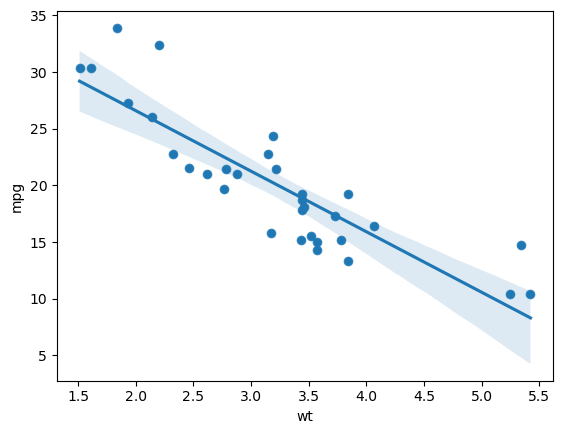

In [4]:
# Data import
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
print(cars.head())

# Visualize the model
sns.scatterplot(x='wt', y='mpg', data=cars)
sns.regplot(x='wt', y='mpg', data=cars)

In [14]:
X_list = cars.wt.values
X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
print(X_np[:4])  # Peak at the first four values to see the shape

y_list = cars.mpg.values.tolist()
y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)

# Create tensors out of the data (two ways)
X = torch.from_numpy(X_np)
y = torch.tensor(y_list)

print("X.shape: {}".format(X.shape))
print("y.shape: {}".format(y.shape))

[[2.62 ]
 [2.875]
 [2.32 ]
 [3.215]]
X.shape: torch.Size([32, 1])
y.shape: torch.Size([32])


In [ ]:
# Randomly initialize weights and bias
w = torch.rand(1, requires_grad=True, dtype=torch.float32)
b = torch.rand(1, requires_grad=True, dtype=torch.float32)


In [38]:
# Training

NUM_EPOCHS = 10000
LR = 0.001

for epoch in range(NUM_EPOCHS):

    for i in range(len(X)):
        
        # Forward pass
        y_pred = X[i] * w + b
        loss_tensor = torch.pow(y_pred - y[i], 2)

        # Backward pass
        loss_tensor.backward()
        # print(loss_tensor.shape)

        loss_value = loss_tensor.data[0]

        # Use no_grad here because we're manually updating the model params and we don't
        # want PyTorch to track those update as part of the computation graph
        # In practice, you'd use an optimizer not manually update like this...
        with torch.no_grad():
            w -= w.grad * LR
            b -= b.grad * LR

            # Zero out the gradients for the next itereration
            w.grad.zero_()
            b.grad.zero_()

    print(loss_value)

tensor(0.9557)
tensor(0.9256)
tensor(0.9121)
tensor(0.9060)
tensor(0.9031)
tensor(0.9018)
tensor(0.9011)
tensor(0.9007)
tensor(0.9005)
tensor(0.9004)
tensor(0.9002)
tensor(0.9001)
tensor(0.9000)
tensor(0.8998)
tensor(0.8997)
tensor(0.8996)
tensor(0.8995)
tensor(0.8994)
tensor(0.8993)
tensor(0.8991)
tensor(0.8990)
tensor(0.8989)
tensor(0.8988)
tensor(0.8987)
tensor(0.8986)
tensor(0.8985)
tensor(0.8984)
tensor(0.8983)
tensor(0.8982)
tensor(0.8981)
tensor(0.8979)
tensor(0.8978)
tensor(0.8977)
tensor(0.8976)
tensor(0.8975)
tensor(0.8974)
tensor(0.8973)
tensor(0.8972)
tensor(0.8971)
tensor(0.8970)
tensor(0.8969)
tensor(0.8968)
tensor(0.8967)
tensor(0.8966)
tensor(0.8965)
tensor(0.8964)
tensor(0.8963)
tensor(0.8962)
tensor(0.8961)
tensor(0.8960)
tensor(0.8959)
tensor(0.8958)
tensor(0.8957)
tensor(0.8956)
tensor(0.8955)
tensor(0.8954)
tensor(0.8953)
tensor(0.8952)
tensor(0.8951)
tensor(0.8950)
tensor(0.8949)
tensor(0.8948)
tensor(0.8947)
tensor(0.8946)
tensor(0.8945)
tensor(0.8944)
tensor(0.8

In [ ]:
# Example of Using an Optimizer instead of manually updating
optimizer = torch.optim.SGD([w, b], lr=LR)

for epoch in range(NUM_EPOCHS):
    for i in range(len(X)):
        y_pred = X[i] * w + b
        loss = (y_pred - y[i]) ** 2
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [39]:
# Visualize the Results

print(f"Weight: {w.item()}, Bias: {b.item()}")

Weight: -5.30604362487793, Bias: 37.07079315185547


Slope: [-5.3444715], Bias: 37.285125732421875


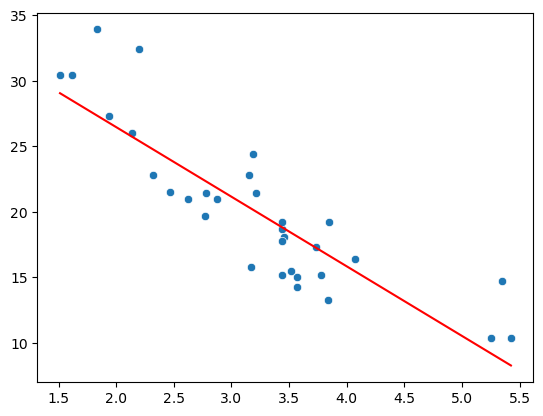

In [40]:
y_pred = (torch.tensor(X_list)*w+b).detach().numpy()

# Our model in a scatterplot
sns.scatterplot(x=X_list, y=y_list)
sns.lineplot(x=X_list, y=y_pred, color='red')

# (Statistical) Linear Regression Model
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_np, y_list)
print(f"Slope: {reg.coef_}, Bias: {reg.intercept_}")